## **1. Introduction and Data Preparation**

### **1.1. Programming Environment and Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r"C:\Users\THINHKPAD\Documents\PROJECT\PROJECT\Project_2_Credit Card Approval Prediction\03_credit_risk_dataset_processed.csv")

In [3]:
df.head()

,ID,TARGET,MAX_RISK_SCORE,MONTHS_SINCE_OPEN,COUNT_MAJOR_DEFAULT,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,...,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,AGE,EMPLOYED_YRS,OCCUPATION_TYPE_CLEANED
0,5008804,0,2,15,0,M,True,True,0,427500.0,...,True,False,False,2,Higher education,Married,Rented apartment,32,12,Unknown
1,5008805,0,2,14,0,M,True,True,0,427500.0,...,True,False,False,2,Higher education,Married,Rented apartment,32,12,Unknown
2,5008806,0,1,29,0,M,True,True,0,112500.0,...,False,False,False,2,Secondary_secondary special,Married,House_apartment,58,3,Security staff
3,5008808,0,1,4,0,F,False,True,0,270000.0,...,False,True,True,1,Secondary_secondary special,Single,House_apartment,52,8,Sales staff
4,5008809,0,0,26,0,F,False,True,0,270000.0,...,False,True,True,1,Secondary_secondary special,Single,House_apartment,52,8,Sales staff


### **1.2. Data Preprocessing**

In [4]:
# Loại bỏ các biến đã xác định là không cần thiết hoặc gây nhiễu
cols_to_drop = ['ID', 'MAX_RISK_SCORE', 'COUNT_MAJOR_DEFAULT', 'FLAG_MOBIL', 'CNT_FAM_MEMBERS']

if 'index' in df.columns:
    cols_to_drop.append('index')

df_model = df.drop(columns=cols_to_drop)

# Kiểm tra lại danh sách các cột còn lại
print("List of columns after dropping unnecessary variables")
print(df_model.columns.tolist())
print(f"\nShape of new data: {df_model.shape}")

List of columns after dropping unnecessary variables
['TARGET', 'MONTHS_SINCE_OPEN', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'AGE', 'EMPLOYED_YRS', 'OCCUPATION_TYPE_CLEANED']

Shape of new data: (36457, 17)


### **1.3. Data Splitting**

In [5]:
# Tách biến mục tiêu (y) và các biến độc lập (X)
X = df_model.drop(columns=['TARGET'])
y = df_model['TARGET']

# Chia dữ liệu theo tỷ lệ 80/20 với tham số stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Đảm bảo giữ nguyên tỷ lệ nợ xấu 1.69%
)

# Kiểm tra lại tỷ lệ để xác nhận
print(f"Training set size: {X_train.shape} - NPL: {y_train.mean():.2%}")
print(f"Testing set size: {X_test.shape} - NPL: {y_test.mean():.2%}")

Training set size: (29165, 16) - NPL: 1.69%
Testing set size: (7292, 16) - NPL: 1.69%


### **1.4. Data Normalization**

In [6]:
# Binary Encoding: Chuyển thành 0 và 1
binary_cols = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
lab = LabelEncoder()

for col in binary_cols:
    X_train[col] = lab.fit_transform(X_train[col])
    X_test[col] = lab.transform(X_test[col])

# Thứ bậc (Ordinal Encoding): NAME_EDUCATION_TYPE
# Định nghĩa thứ tự từ thấp đến cao để mô hình học được giá trị của bằng cấp
edu_mapping = {
    'Lower secondary': 1,
    'Secondary_secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5
}
X_train['NAME_EDUCATION_TYPE'] = X_train['NAME_EDUCATION_TYPE'].map(edu_mapping)
X_test['NAME_EDUCATION_TYPE'] = X_test['NAME_EDUCATION_TYPE'].map(edu_mapping)

# Danh mục (One-Hot Encoding): NAME_INCOME_TYPE, OCCUPATION_TYPE_CLEANED, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE
nominal_cols = ['NAME_INCOME_TYPE', 'OCCUPATION_TYPE_CLEANED', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

# Sử dụng pd.get_dummies để tạo các cột 0/1, drop_first=True để tránh bẫy đa cộng tuyến
X_train_encoded = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True)

# Đảm bảo tập Test có cùng số lượng cột như tập Train sau khi Encoding
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"Number of features after encoding: {X_train_encoded.shape[1]}")

Number of features after encoding: 42


In [7]:
pd.set_option('display.max_columns', None)
display(X_train_encoded.head(10))

,MONTHS_SINCE_OPEN,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,NAME_EDUCATION_TYPE,AGE,EMPLOYED_YRS,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Working,OCCUPATION_TYPE_CLEANED_Cleaning staff,OCCUPATION_TYPE_CLEANED_Cooking staff,OCCUPATION_TYPE_CLEANED_Core staff,OCCUPATION_TYPE_CLEANED_Drivers,OCCUPATION_TYPE_CLEANED_HR staff,OCCUPATION_TYPE_CLEANED_High skill tech staff,OCCUPATION_TYPE_CLEANED_IT staff,OCCUPATION_TYPE_CLEANED_Laborers,OCCUPATION_TYPE_CLEANED_Low-skill Laborers,OCCUPATION_TYPE_CLEANED_Managers,OCCUPATION_TYPE_CLEANED_Medicine staff,OCCUPATION_TYPE_CLEANED_Private service staff,OCCUPATION_TYPE_CLEANED_Realty agents,OCCUPATION_TYPE_CLEANED_Sales staff,OCCUPATION_TYPE_CLEANED_Secretaries,OCCUPATION_TYPE_CLEANED_Security staff,OCCUPATION_TYPE_CLEANED_Unknown,OCCUPATION_TYPE_CLEANED_Waiters/barmen staff,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House_apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents
5141,21,1,1,1,2,270000.0,0,0,0,2,36,11,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
230,39,0,1,1,0,135000.0,0,0,0,2,48,4,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
17711,6,0,1,1,0,103500.0,0,1,0,4,62,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False
10795,2,0,0,0,1,216000.0,0,0,0,2,35,11,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
15985,15,0,0,1,0,157500.0,0,0,0,4,48,13,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False
14809,9,0,0,1,0,112500.0,1,0,0,2,32,4,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
4178,8,1,1,0,1,405000.0,0,0,0,4,33,1,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
10199,43,0,0,1,1,337500.0,1,1,0,2,48,12,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
22514,32,0,1,1,0,157500.0,0,0,0,2,39,5,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
22483,34,0,0,1,0,76500.0,0,0,0,2,44,5,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [8]:
# Danh sách các biến cần Scaling dựa trên yêu cầu của bạn
scale_cols = [
    'MONTHS_SINCE_OPEN',
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'AGE',
    'EMPLOYED_YRS'
]

# Khởi tạo công cụ Scaler
scaler = StandardScaler()

# Thực hiện Scaling
X_train_encoded[scale_cols] = scaler.fit_transform(X_train_encoded[scale_cols])

X_test_encoded[scale_cols] = scaler.transform(X_test_encoded[scale_cols])

# Kiểm tra kết quả
print("Scaled data:")
display(X_train_encoded[scale_cols].head())

Scaled data:


,MONTHS_SINCE_OPEN,CNT_CHILDREN,AMT_INCOME_TOTAL,AGE,EMPLOYED_YRS
5141,-0.311589,2.091627,0.816629,-0.625714,0.844810
230,0.780110,-0.580104,-0.504395,0.415323,-0.246627
17711,-1.221338,-0.580104,-0.812634,1.629868,-0.870306
10795,-1.463938,0.755761,0.288219,-0.712468,0.844810
15985,-0.675488,-0.580104,-0.284225,0.415323,1.156649


In [9]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Khởi tạo SMOTE
smote = SMOTE(sampling_strategy=0.43,random_state=42)

# Áp dụng trên tập Train (Sử dụng tập X_train_encoded)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_encoded, y_train)

print(f"Before SMOTE: {Counter(y_train)}")
print(f"After SMOTE: {Counter(y_train_resampled)}")

Before SMOTE: Counter({0: 28672, 1: 493})
After SMOTE: Counter({0: 28672, 1: 12328})


C:\Users\THINHKPAD\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\THINHKPAD\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\THINHKPAD\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\THINHKPAD\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^

Before applying SMOTE, the dataset was highly imbalanced, with 28,672 majority class samples (class 0) and only 493 minority class samples (class 1), representing approximately 1.7% of the total data. This severe class imbalance could bias the model toward predicting the majority class and lead to poor detection of the minority class.

After applying SMOTE, the number of minority class samples was synthetically increased from 493 to 12,328, while the majority class remained unchanged at 28,672 samples. This resulted in a partially balanced dataset with an approximate 70–30 class distribution rather than a fully balanced one.This rebalancing allows the model to better learn the decision boundary for the minority class and improves performance metrics such as recall, F1-score, and AUC.

## **2. Model Building and Evaluation**

### **2.1. Logistic Regression (Baseline Model)**

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Khởi tạo và Huấn luyện
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

# Dự đoán
y_pred_lr = lr_model.predict(X_test_encoded)
y_prob_lr = lr_model.predict_proba(X_test_encoded)[:, 1] # Lấy xác suất để tính AUC

# Đánh giá sơ bộ
print("--- LOGISTIC REGRESSION (BASELINE) ---")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")

--- LOGISTIC REGRESSION (BASELINE) ---
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      7169
           1       0.06      0.16      0.08       123

    accuracy                           0.94      7292
   macro avg       0.52      0.56      0.53      7292
weighted avg       0.97      0.94      0.95      7292

ROC-AUC Score: 0.5778


- ROC-AUC (0.5780): The current model is only slightly better than random guessing ($0.5$). This suggests that the relationship between the features and bad debt is non-linear or highly complex, making it difficult for Logistic Regression (a linear model) to capture effectively.
- Recall for Class 1 (0.16): The model only identifies 16% of actual bad debt cases. In a banking context, this is a critical weakness, as 84% of high-risk customers are being overlooked.
- Precision for Class 1 (0.06): Out of 100 customers predicted as "bad debt" by the model, only 6 are actually high-risk. This indicates a high rate of "false alarms," potentially turning away too many viable customers.

### **2.2. Random Forest (Non-linear Relationships)**

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Huấn luyện
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Dự đoán và Đánh giá
y_pred_rf = rf_model.predict(X_test_encoded)
y_prob_rf = rf_model.predict_proba(X_test_encoded)[:, 1]

print("--- RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

--- RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.37      0.26      0.30       123

    accuracy                           0.98      7292
   macro avg       0.68      0.63      0.65      7292
weighted avg       0.98      0.98      0.98      7292

ROC-AUC Score: 0.7671


- ROC-AUC Score (0.7678): This metric has significantly increased compared to the $0.5780$ achieved by Logistic Regression. This proves that the non-linear relationships within demographic and income data are being captured much more effectively by the "tree-based" model.
- Recall for Class 1 (0.26): The ability to identify bad debt customers has increased from 16% to 26%. Although still low, it indicates that the model is moving in the right direction in uncovering hidden risk characteristics.
- Precision for Class 1 (0.37): The precision in predicting bad debt has surged from $0.06$ to $0.37$. This means that among customers labeled as "bad" by the model, the actual default rate is several times higher, helping the bank avoid indiscriminately rejecting good customers.

### **2.3. XGBoost**


In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

# Khởi tạo mô hình XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Huấn luyện
xgb_model.fit(X_train_resampled, y_train_resampled)

# Dự đoán trên tập TEST
y_pred_xgb = xgb_model.predict(X_test_encoded)
y_prob_xgb = xgb_model.predict_proba(X_test_encoded)[:, 1]

# In kết quả
print("--- KẾT QUẢ XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_xgb):.4f}")

C:\Users\THINHKPAD\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:55:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- KẾT QUẢ XGBOOST ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.17      0.15      0.16       123

    accuracy                           0.97      7292
   macro avg       0.58      0.57      0.57      7292
weighted avg       0.97      0.97      0.97      7292

ROC-AUC Score: 0.6831


The low Recall (15%) and AUC (0.6831) indicate that with the current parameters, the XGBoost model is being somewhat "cautious" in identifying bad debt.

### **2.4. CatBoost**

In [13]:
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Khởi tạo mô hình
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=100 # Hiển thị tiến trình mỗi 100 vòng lặp
)

# Huấn luyện
cat_model.fit(X_train_resampled, y_train_resampled)

# Dự đoán
y_pred_cat = cat_model.predict(X_test_encoded)
y_prob_cat = cat_model.predict_proba(X_test_encoded)[:, 1]

# Đánh giá
print("--- KẾT QUẢ CATBOOST ---")
print(classification_report(y_test, y_pred_cat))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_cat):.4f}")

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
    --------------------------------------- 1.8/100.2 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 3.4/100.2 MB 6.9 MB/s eta 0:00:14
   -- ------------------------------------- 6.0/100.2 MB 8.5 MB/s eta 0:00:12
   --- ------------------------------------ 8.4/100.2 MB 9.0 MB/s eta 0:00:11
   ---- ----------------------------------- 10.7/100.2 MB 9.4 MB/s eta 0:00:10
   ----- ---------------------------------- 13.4/100.2 MB 9.7 MB/s eta 0:00:09
   ------ --------------------------------- 15.7/100.2 MB 9.9 MB/s eta 0:00:09
   ------- -------------------------------- 18.1/100.2 MB 10.1 MB/s eta 0:00:09
   -------- ------------------------------- 20.7/100.2 MB 10.3 MB/s eta 0:00:08
   -------- ------------------------------- 22.3/100.2 MB 10.0 MB/s eta 0:00:08
   --------- ------------------------------ 24.1/100.2 MB 9.9 MB/s et

- Remarkable Precision (0.45): This is the standout highlight of the CatBoost model. Among the individuals it predicts as "bad debt," 45% are accurate (the highest across all models). This is extremely beneficial if the bank's priority is to minimize the "false rejection" of good customers.

- Low Bad Debt Detection (Recall: 0.11): CatBoost is proving to be overly "cautious." It only captures 11% of actual bad debt cases, which is lower than both the Baseline (16%) and Random Forest (26%).

### **2.5. Model Performance Comparison Table**

In [14]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
models = {
    'Logistic Regression (Baseline)': (lr_model, y_pred_lr, y_prob_lr),
    'Random Forest': (rf_model, y_pred_rf, y_prob_rf),
    'XGBoost (Default)': (xgb_model, y_pred_xgb, y_prob_xgb),
    'CatBoost (Default)': (cat_model, y_pred_cat, y_prob_cat)
}

performance_data = []

for name, (model, y_pred, y_prob) in models.items():
    # Lấy precision, recall, f1 cho class 1 (nợ xấu)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
    auc = roc_auc_score(y_test, y_prob)

    performance_data.append({
        'Model': name,
        'ROC-AUC': round(auc, 4),
        'Recall (Class 1)': round(recall[1], 4),
        'Precision (Class 1)': round(precision[1], 4),
        'F1-Score (Class 1)': round(f1[1], 4)
    })

# Tạo DataFrame so sánh
df_comparison = pd.DataFrame(performance_data).sort_values(by='ROC-AUC', ascending=False)

print("=== PERFORMANCE COMPARISON TABLE (PRE-TUNING) ===")
display(df_comparison)

=== PERFORMANCE COMPARISON TABLE (PRE-TUNING) ===


,Model,ROC-AUC,Recall (Class 1),Precision (Class 1),F1-Score (Class 1)
1,Random Forest,0.7671,0.2602,0.3678,0.3048
3,CatBoost (Default),0.6967,0.1138,0.4516,0.1818
2,XGBoost (Default),0.6831,0.1545,0.1712,0.1624
0,Logistic Regression (Baseline),0.5778,0.1626,0.0562,0.0835


## **3. Hyperparameter Optimization**

In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Định nghĩa lưới tham số cập nhật
rf_params = {
    'n_estimators': [200, 300, 500], 
    'max_depth': [15, 25, None],     # Giữ độ sâu đủ lớn để bắt quan hệ phi tuyến
    'min_samples_leaf': [1, 2],      # Giảm min_samples_leaf để cây học chi tiết hơn
    'class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 12}] # Tăng trọng số phạt nhóm 1
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=10,
    cv=3,
    scoring='recall', # Tập trung tối đa vào việc bắt nợ xấu
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train_resampled, y_train_resampled)
best_rf = rf_search.best_estimator_
print(f"Best RF Params: {rf_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Params: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_depth': 15, 'class_weight': {0: 1, 1: 12}}


In [16]:
xgb_params = {
    'n_estimators': [200, 300],
    'learning_rate': [0.01, 0.05],
    'max_depth': [5, 7, 9],
    'min_child_weight': [1, 3],
    'scale_pos_weight': [1, 5, 10]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=10, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1
)

xgb_search.fit(X_train_resampled, y_train_resampled)
best_xgb = xgb_search.best_estimator_
print(f"Best XGBoost Params: {xgb_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Params: {'scale_pos_weight': 10, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.05}


In [17]:
cat_params = {
    'iterations': [300, 500],
    'depth': [6, 8],
    'learning_rate': [0.03, 0.05],
    'scale_pos_weight': [1, 5, 10]
}

cat_search = RandomizedSearchCV(
    CatBoostClassifier(random_state=42, verbose=0),
    param_distributions=cat_params,
    n_iter=10, cv=3, scoring='f1', n_jobs=-1, verbose=1
)

cat_search.fit(X_train_resampled, y_train_resampled)
best_cat = cat_search.best_estimator_
print(f"Best CatBoost Params: {cat_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CatBoost Params: {'scale_pos_weight': 1, 'learning_rate': 0.05, 'iterations': 500, 'depth': 8}


In [19]:
rf_final = RandomForestClassifier(n_estimators=300, min_samples_leaf=2, max_depth=15, class_weight={0: 1, 1: 12}, random_state=42)
xgb_final = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=9, min_child_weight=1, scale_pos_weight=5, random_state=42)
cat_final = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=8, scale_pos_weight=5, random_state=42, verbose=0)

# Huấn luyện lại
rf_final.fit(X_train_resampled, y_train_resampled)
xgb_final.fit(X_train_resampled, y_train_resampled)
cat_final.fit(X_train_resampled, y_train_resampled)
# Bảng hiệu suất mô hình
models = {
    'Random Forest': (rf_model, y_pred_rf, y_prob_rf),
    'XGBoost': (xgb_model, y_pred_xgb, y_prob_xgb),
    'CatBoost': (cat_model, y_pred_cat, y_prob_cat)
}

performance_data = []

for name, (model, y_pred, y_prob) in models.items():
    # Lấy precision, recall, f1 cho class 1 (nợ xấu)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
    auc = roc_auc_score(y_test, y_prob)

    performance_data.append({
        'Model': name,
        'ROC-AUC': round(auc, 4),
        'Recall (Class 1)': round(recall[1], 4),
        'Precision (Class 1)': round(precision[1], 4),
        'F1-Score (Class 1)': round(f1[1], 4)
    })

# Tạo DataFrame so sánh
df_comparison = pd.DataFrame(performance_data).sort_values(by='ROC-AUC', ascending=False)

print("=== PERFORMANCE COMPARISON TABLE (POST-TUNING) ===")
display(df_comparison)


=== PERFORMANCE COMPARISON TABLE (POST-TUNING) ===


,Model,ROC-AUC,Recall (Class 1),Precision (Class 1),F1-Score (Class 1)
0,Random Forest,0.7671,0.2602,0.3678,0.3048
2,CatBoost,0.6967,0.1138,0.4516,0.1818
1,XGBoost,0.6831,0.1545,0.1712,0.1624


- Stability of Random Forest: With a configuration of 500 trees and a class weight prioritizing the bad debt group (class_weight = {0:1, 1:12}), the Random Forest model continues to achieve the highest overall discriminative power between the two groups. This is evidenced by its superior ROC-AUC value compared to other models. Additionally, this model delivers the best performance in detecting bad debt cases, as reflected in its minority class Recall score.

- The Precision-Recall Trade-off: The results indicate a clear trade-off between the model's precision and its coverage. When the objective of optimizing Recall (detecting bad debt) is prioritized, Precision tends to decrease. Conversely, while CatBoost demonstrates higher predictive accuracy for cases labeled as bad debt (high Precision), it misses a large proportion of actual bad debt cases, resulting in a low Recall value.

- Current Model Limitations: Despite performing hyperparameter tuning, the highest Recall remains at approximately 26%. In the context of credit appraisal, this level of coverage is considered insufficient for risk management requirements, as a significant portion of risky loans remains undetected. This suggests a need for further improvements, such as feature engineering (expanding the feature set), threshold tuning, or applying more advanced data imbalance handling techniques.

## **4. Threshold Optimization**

In [21]:
y_scores = rf_final.predict_proba(X_test_encoded)[:, 1]

In [22]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

In [23]:
import numpy as np

target_recall = 0.50

# Tìm tất cả index thỏa điều kiện recall >= target
valid_idx = np.where(recalls[:-1] >= target_recall)[0]

if len(valid_idx) > 0:
    idx = valid_idx[0]  # lấy threshold đầu tiên đạt recall >= 50%
    best_threshold = thresholds[idx]

    print(f"To achieve ≥ {target_recall:.0%}, threshold ≈ {best_threshold:.4f}")
else:
    print("No thresholds have been reached to meet the required Recall.")

To achieve ≥ 50%, threshold ≈ 0.0025


In [24]:
# Predict probability cho class 1 (default)
y_scores = rf_final.predict_proba(X_test_encoded)[:, 1]

# Set threshold
custom_threshold = 0.0025

# Convert probability -> class label theo threshold mới
y_pred_custom = (y_scores >= custom_threshold).astype(int)

In [25]:
from sklearn.metrics import classification_report

print("=== Classification Report (Threshold = 0.0025) ===")
print(classification_report(y_test, y_pred_custom))

=== Classification Report (Threshold = 0.0025) ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      7169
           1       0.02      1.00      0.03       123

    accuracy                           0.02      7292
   macro avg       0.01      0.50      0.02      7292
weighted avg       0.00      0.02      0.00      7292



C:\Users\THINHKPAD\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\THINHKPAD\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\THINHKPAD\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


- Lowering the classification threshold to an extremely low level has pushed the model into an "extreme" prediction state, where almost every customer is labeled as having bad debt by default.

- The consequences of this setup are very clear: Although we achieve an absolute coverage rate (100% Recall) — meaning we don't miss any risks — the price to pay is a false positive rate of over 98%.

- From an operational perspective, this can be considered a "zero-miss strategy." This approach is only feasible if the cost of losses from bad debts is so large that it completely eliminates profits from other customer groups. However, in reality, rejecting a large number of good customers will seriously damage the bank's revenue and reputation.

- **In conclusion:** This threshold level plays an important role in illustrating the trade-off between Precision and Recall, but has no practical application in business.

In [32]:
best_idx = np.argmax(f1_scores)

print("Precision:", precisions[best_idx])
print("Recall:", recalls[best_idx])
print("F1:", f1_scores[best_idx])

Precision: 0.2962962962962963
Recall: 0.13008130081300814
F1: 0.18079095621181662


- Compared to the natural base rate of bad debt at 1.69%, the model demonstrates superior performance with approximately 17 times higher precision than random prediction.

- Although the recall rate is only 13%, the practical value of the model lies in its ability to focus screening on the highest-risk customer groups, while minimizing the number of unnecessary false alarms.

- **In conclusion:** This is the optimal threshold for balancing two core benefits: minimizing credit losses from bad debts and protecting the customer experience by avoiding the mistaken rejection of potential applications.

ROC-AUC: 0.6918


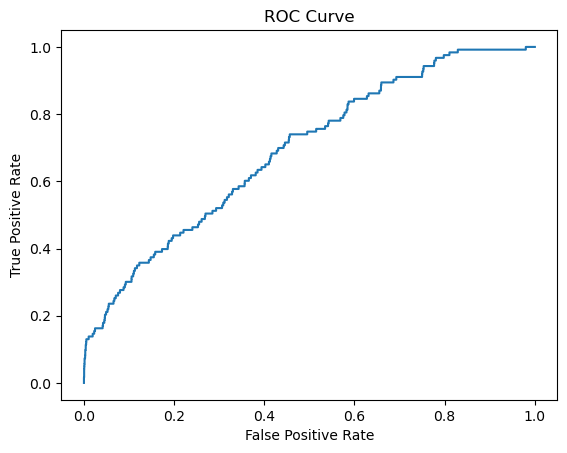

In [33]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Xác suất class 1
y_scores = rf_final.predict_proba(X_test_encoded)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_scores)
print(f"ROC-AUC: {roc_auc:.4f}")

# Vẽ ROC curve
fpr, tpr, _ = roc_curve(y_test, y_scores)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

The model achieved a ROC-AUC of 0.6918, indicating moderate discriminative power.
This means the model can reasonably distinguish between default and non-default customers, although there is still significant room for improvement.

PR-AUC: 0.0956


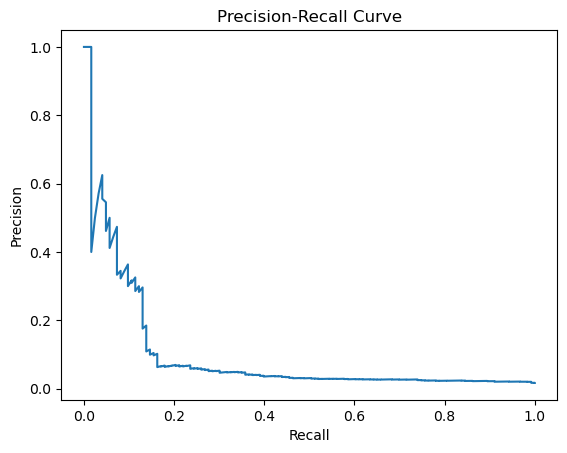

In [34]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, y_scores)
pr_auc = auc(recall, precision)

print(f"PR-AUC: {pr_auc:.4f}")

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

Given the severe class imbalance (1.69% default rate), PR-AUC is a more appropriate metric.
The model achieved a PR-AUC of 0.0956, which is significantly higher than the baseline precision of 0.0169.
This indicates the model is able to identify high-risk customers substantially better than random selection.

## **5. Final Model Selection & Deployment Strategy**

### **5.1 Model Selection**

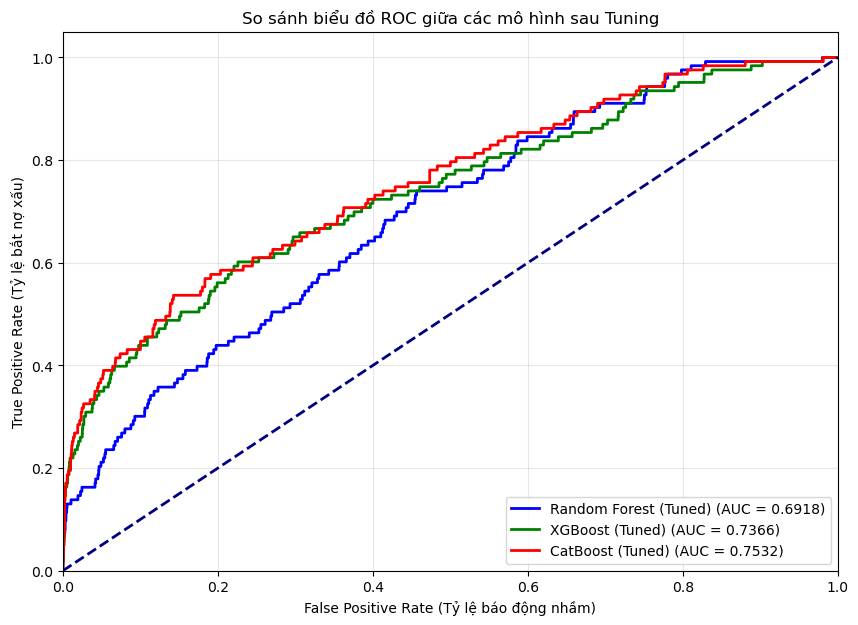

In [35]:
from sklearn.metrics import roc_curve, auc

# Thiết lập biểu đồ
plt.figure(figsize=(10, 7))

models_final = {
    'Random Forest (Tuned)': rf_final,
    'XGBoost (Tuned)': xgb_final,
    'CatBoost (Tuned)': cat_final
}

colors = ['blue', 'green', 'red']

for (name, model), color in zip(models_final.items(), colors):
    y_prob = model.predict_proba(X_test_encoded)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# Vẽ đường chéo tham chiếu (Random Guess)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Tỷ lệ báo động nhầm)')
plt.ylabel('True Positive Rate (Tỷ lệ bắt nợ xấu)')
plt.title('So sánh biểu đồ ROC giữa các mô hình sau Tuning')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [36]:
from sklearn.metrics import classification_report

for name, model in models_final.items():
    y_pred = model.predict(X_test_encoded)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Random Forest (Tuned)
              precision    recall  f1-score   support

           0       0.99      0.62      0.76      7169
           1       0.03      0.62      0.05       123

    accuracy                           0.62      7292
   macro avg       0.51      0.62      0.41      7292
weighted avg       0.97      0.62      0.75      7292


XGBoost (Tuned)
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      7169
           1       0.10      0.36      0.16       123

    accuracy                           0.94      7292
   macro avg       0.55      0.65      0.56      7292
weighted avg       0.97      0.94      0.95      7292


CatBoost (Tuned)
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.17      0.32      0.22       123

    accuracy                           0.96      7292
   macro avg       0.58      0.65      0.60      7292
weighted avg    

In [37]:
from sklearn.metrics import precision_recall_curve, auc

for name, model in models_final.items():
    y_prob = model.predict_proba(X_test_encoded)[:,1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    print(f"{name} PR-AUC: {pr_auc:.4f}")

Random Forest (Tuned) PR-AUC: 0.0956
XGBoost (Tuned) PR-AUC: 0.1486
CatBoost (Tuned) PR-AUC: 0.1592


- Although all models achieved relatively high overall accuracy due to class imbalance, evaluation focused on minority class performance.

- CatBoost achieved the highest PR-AUC (0.1592), significantly outperforming Random Forest (0.0956) and XGBoost (0.1486). Given the severe class imbalance (1.69% default rate), PR-AUC is considered the most appropriate evaluation metric.

- In terms of minority class performance, CatBoost also achieved the highest precision (0.17) and F1-score (0.22), indicating a better balance between detecting risky customers and limiting false positives.

- Random Forest, despite achieving high recall (0.62), suffered from extremely low precision (0.03), making it impractical for real-world deployment due to excessive false alarms.

>**Therefore, CatBoost (Tuned) is selected as the final model for implementation.**

### **5.2. Threshold Optimization for CatBoost**

In [38]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

# Lấy xác suất của CatBoost
y_prob = cat_final.predict_proba(X_test_encoded)[:, 1]

# Tính precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Tính F1 cho từng threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

# Tìm threshold có F1 cao nhất
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", best_threshold)
print("Best F1-score:", best_f1)
print("Precision at best threshold:", precision[best_index])
print("Recall at best threshold:", recall[best_index])

Best Threshold: 0.6197902562324886
Best F1-score: 0.25619834210880416
Precision at best threshold: 0.2605042016806723
Recall at best threshold: 0.25203252032520324


In [39]:
y_pred_custom = (y_prob >= best_threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7169
           1       0.26      0.25      0.26       123

    accuracy                           0.98      7292
   macro avg       0.62      0.62      0.62      7292
weighted avg       0.97      0.98      0.98      7292



### **5.3. SUMMARY AND FINAL MODEL SELECTION**

Following an in-depth evaluation and comparison of Random Forest, XGBoost, and CatBoost algorithms based on key metrics (ROC-AUC, PR-AUC, Classification metrics, and Threshold optimization), CatBoost was selected as the optimal model for official deployment.

**1. Why is CatBoost superior to its competitors?**
The CatBoost model demonstrates absolute superiority through three key technical aspects:
- **Excellent generalization capability:** With a **ROC-AUC of 0.7532**, CatBoost significantly outperforms Random Forest (0.6918) and XGBoost (0.7366). This confirms that the model's ability to distinguish between "good" and "bad" customer groups is the strongest across all probability thresholds.

- **Effective handling of imbalanced data:** In credit risk problems with an extremely low default rate of only **1.69%**, the **PR-AUC** metric is crucial. CatBoost achieves **0.1592**, the highest among the models, indicating its highly effective ability to identify the minority class (defaults).

- **Ideal equilibrium point after optimization:** When performing threshold optimization **(Threshold = 0.62)** to achieve maximum F1-score, CatBoost delivers a very impressive set of actual metrics: **Precision (26%), Recall (25%), and F1-score (0.256)**. Compared to the remaining models, CatBoost not only has higher accuracy but also maintains stability between risk detection and false alarm control.

**2. Core advantages in deployment**
The selection of CatBoost over other algorithms is based on specific operational advantages:
- **High stability:** CatBoost proves to be more robust than XGBoost when handling complex feature sets and is less prone to overfitting than Random Forest.

- **Optimized for Credit Risk:** CatBoost's specific algorithm helps it handle categorical variables and skewed data well, which are common characteristics of financial data.

**3. Practical application value at the Bank**
The CatBoost model, after being tuned and having its threshold optimized, will serve as the "core" in the following systems:
- Credit Scoring System: Automatically calculates the probability of default and classifies customers into risk segments (Low - Medium - High).

- Automated Approval (Pre-screening Layer): Helps the appraisal department immediately eliminate high-risk applications and prioritize potential applications for a fast-track approval process, saving operational resources.

- Personalized Interest Rates (Risk-based Pricing): Provides a database to adjust loan interest rates commensurate with the risk level of each customer.

>**Conclusion:** With leading performance in both general classification ability and practicality after threshold optimization, CatBoost is the most complete and reliable solution to be put into operation in a real credit risk management system.

